In [1]:
# Cell 1 — Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Cell 2 — Load Dataset
df = pd.read_csv('/kaggle/input/datasets/fabdelja/autism-screening-for-toddlers/Toddler Autism dataset July 2018.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1054, 19)

Columns: ['Case_No', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits ']

First 5 rows:


,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


In [3]:
# Cell 3 — Basic Info and Missing Values
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nClass Distribution:")
print(df['Class/ASD Traits '].value_counts())
print("\nClass Distribution (%):")
print(df['Class/ASD Traits '].value_counts(normalize=True) * 100)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Case_No                 1054 non-null   int64 
 1   A1                      1054 non-null   int64 
 2   A2                      1054 non-null   int64 
 3   A3                      1054 non-null   int64 
 4   A4                      1054 non-null   int64 
 5   A5                      1054 non-null   int64 
 6   A6                      1054 non-null   int64 
 7   A7                      1054 non-null   int64 
 8   A8                      1054 non-null   int64 
 9   A9                      1054 non-null   int64 
 10  A10                     1054 non-null   int64 
 11  Age_Mons                1054 non-null   int64 
 12  Qchat-10-Score          1054 non-null   int64 
 13  Sex                     1054 non-null   object
 14  Ethnicity               1054 non-null   ob

/tmp/ipykernel_16/1702672443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class/ASD Traits ', data=df, palette=['#2ecc71', '#e74c3c'])


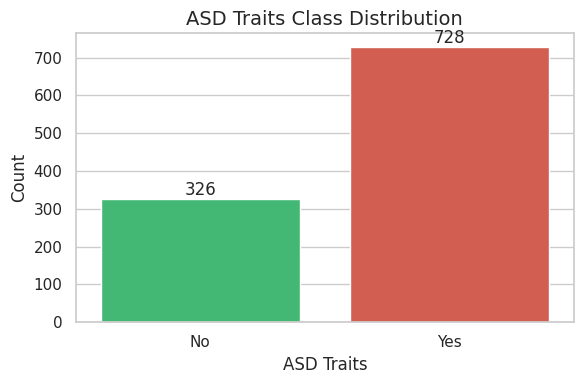

In [4]:
# Cell 4 — Class Distribution Plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Class/ASD Traits ', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('ASD Traits Class Distribution', fontsize=14)
plt.xlabel('ASD Traits')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

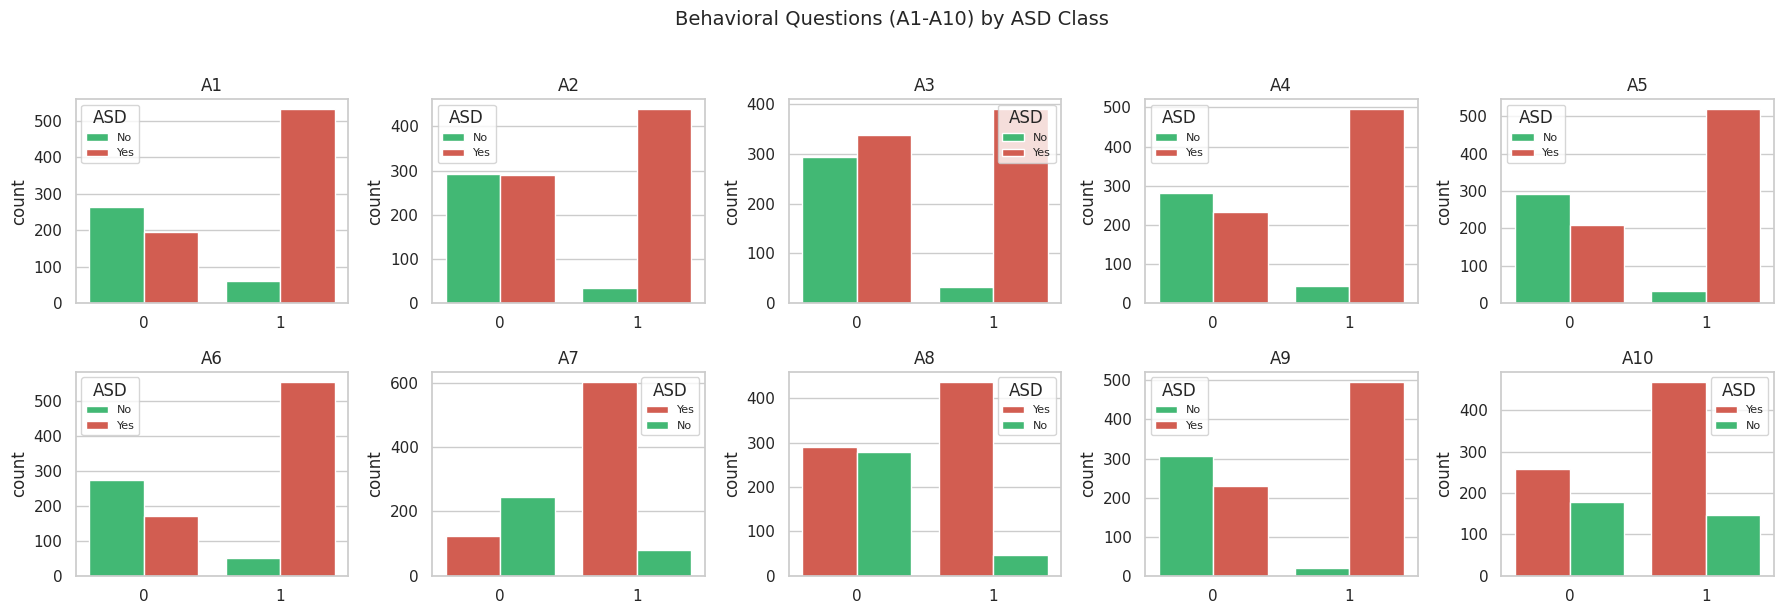

In [5]:
# Cell 5 — Behavioral Features Distribution (A1-A10)
behavioral_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(behavioral_cols):
    sns.countplot(x=col, hue='Class/ASD Traits ', data=df, 
                  palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[i])
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].legend(title='ASD', fontsize=8)

plt.suptitle('Behavioral Questions (A1-A10) by ASD Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

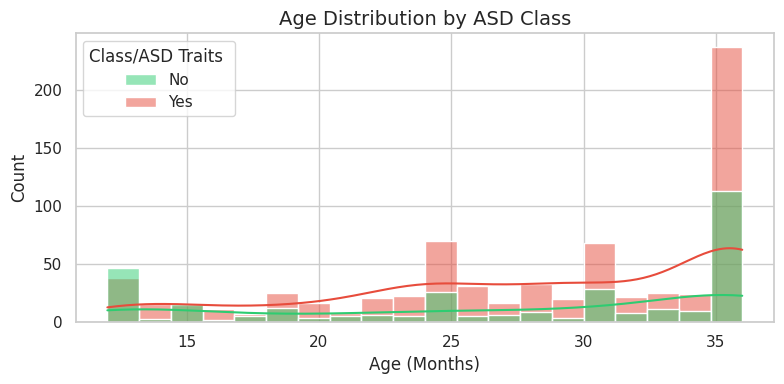


Age stats by class:
                   count       mean       std   min   25%   50%   75%   max
Class/ASD Traits                                                           
No                 326.0  27.070552  8.936593  12.0  19.0  30.0  36.0  36.0
Yes                728.0  28.223901  7.491995  12.0  24.0  30.0  36.0  36.0


In [6]:
# Cell 6 — Age Distribution by ASD Class
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age_Mons', hue='Class/ASD Traits ',
             palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
             bins=20, kde=True)
plt.title('Age Distribution by ASD Class', fontsize=14)
plt.xlabel('Age (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("\nAge stats by class:")
print(df.groupby('Class/ASD Traits ')['Age_Mons'].describe())

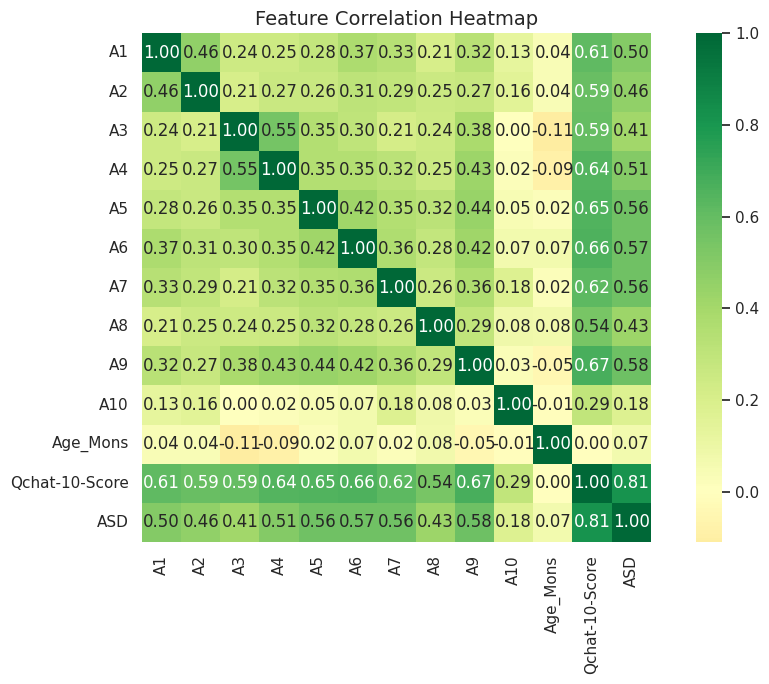

In [7]:
# Cell 7 — Correlation Heatmap of Behavioral Features
plt.figure(figsize=(10, 7))

# Create a copy with binary target for correlation
df_corr = df.copy()
df_corr['ASD'] = (df_corr['Class/ASD Traits '] == 'Yes').astype(int)

cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 
        'Age_Mons', 'Qchat-10-Score', 'ASD']

sns.heatmap(df_corr[cols].corr(), annot=True, fmt='.2f', 
            cmap='RdYlGn', center=0, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

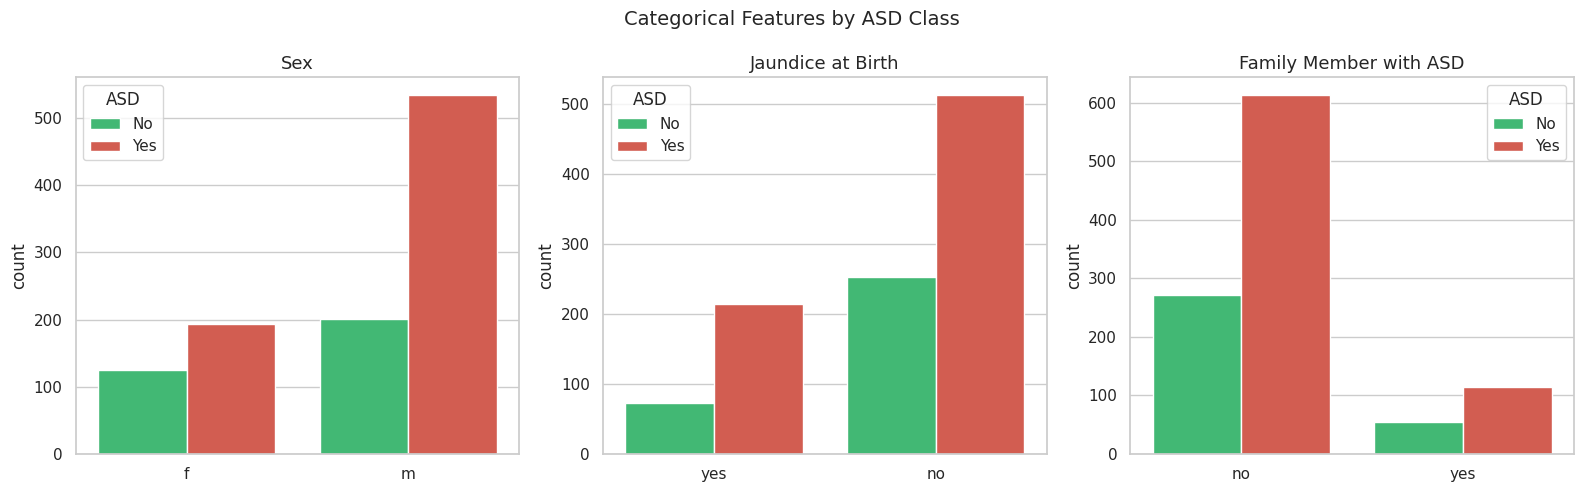

In [8]:
# Cell 8 — Categorical Features Analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cat_cols = ['Sex', 'Jaundice', 'Family_mem_with_ASD']
titles = ['Sex', 'Jaundice at Birth', 'Family Member with ASD']

for i, (col, title) in enumerate(zip(cat_cols, titles)):
    sns.countplot(x=col, hue='Class/ASD Traits ',
                  data=df, palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
                  ax=axes[i])
    axes[i].set_title(title, fontsize=13)
    axes[i].set_xlabel('')
    axes[i].legend(title='ASD')

plt.suptitle('Categorical Features by ASD Class', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Cell 9 — Exploration Summary
print("=" * 50)
print("DATA EXPLORATION SUMMARY")
print("=" * 50)
print(f"Total samples: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")
print(f"Missing values: None")
print(f"\nClass distribution:")
print(f"  ASD Positive (Yes): 728 (69.1%)")
print(f"  ASD Negative (No):  326 (30.9%)")
print(f"\nKey findings:")
print(f"  - Qchat-10-Score has highest ASD correlation (0.81)")
print(f"  - A6, A9, A5 are strongest individual behavioral predictors")
print(f"  - A10 is weakest behavioral feature (0.18 correlation)")
print(f"  - Age has almost no predictive value (0.07 correlation)")
print(f"  - Males more ASD positive than females")
print(f"  - Family history is a meaningful risk factor")
print(f"\nPreprocessing plan:")
print(f"  - Drop: Case_No, Qchat-10-Score (leakage), Who completed the test")
print(f"  - Encode: Sex, Ethnicity, Jaundice, Family_mem_with_ASD")
print(f"  - Handle imbalance: class_weight in XGBoost")
print(f"  - Target: Class/ASD Traits -> binary (0/1)")
print("=" * 50)

DATA EXPLORATION SUMMARY
Total samples: 1054
Total features: 19
Missing values: None

Class distribution:
  ASD Positive (Yes): 728 (69.1%)
  ASD Negative (No):  326 (30.9%)

Key findings:
  - Qchat-10-Score has highest ASD correlation (0.81)
  - A6, A9, A5 are strongest individual behavioral predictors
  - A10 is weakest behavioral feature (0.18 correlation)
  - Age has almost no predictive value (0.07 correlation)
  - Males more ASD positive than females
  - Family history is a meaningful risk factor

Preprocessing plan:
  - Drop: Case_No, Qchat-10-Score (leakage), Who completed the test
  - Encode: Sex, Ethnicity, Jaundice, Family_mem_with_ASD
  - Handle imbalance: class_weight in XGBoost
  - Target: Class/ASD Traits -> binary (0/1)
